# RetinaMNIST Diabetic Retinopathy Classification

In [1]:
!pip install medmnist torchinfo

## 1. Environment setup and fix random seed

In [2]:
# imports and fix random seeds
import random
import numpy as np
import os
import hashlib
from matplotlib import pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2

import torch
from torch import nn
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torchinfo import summary

from medmnist import RetinaMNIST


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PREPROCESSED_DIR = "/content/preprocessed"

set_seed(SEED)

## 2. Load the dataset

In [3]:
train_dataset = RetinaMNIST(split='train', download=True, size=224)
val_dataset = RetinaMNIST(split='val', download=True, size=224)
test_dataset = RetinaMNIST(split='test', download=True, size=224)

## 3. Data exploration and preprocessing

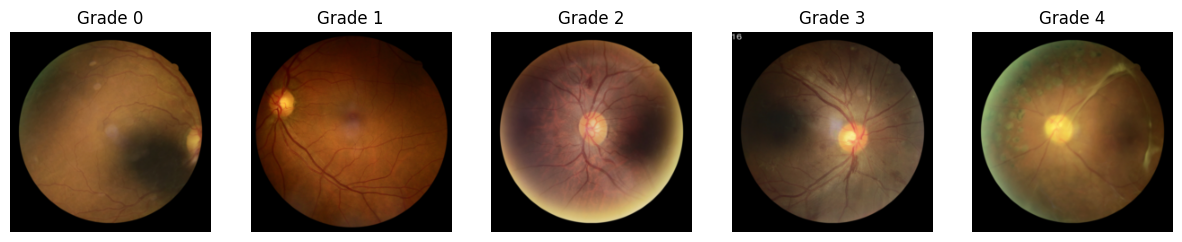

In [4]:
classes = np.unique(train_dataset.labels.flatten())

sample_images = []
for c in classes:
    labels_flat = train_dataset.labels.flatten()
    idx = np.where(labels_flat == c)[0][0]
    img_arr = np.squeeze(train_dataset.imgs[idx])
    sample_images.append(img_arr)

plt.figure(figsize=(15, 5))
for i, img_arr in enumerate(sample_images):
    plt.subplot(1, len(sample_images), i + 1)
    if img_arr.ndim == 3:
        plt.imshow(img_arr)
    else:
        plt.imshow(img_arr, cmap='gray')
    plt.title(f'Grade {int(classes[i])}')
    plt.axis('off')
plt.show()

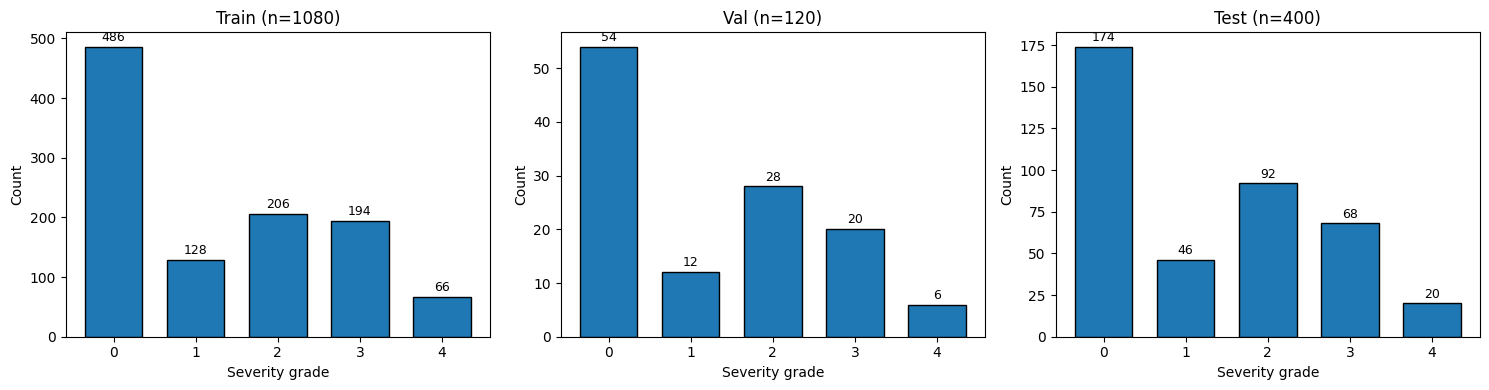

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split_name, dataset in zip(axes,
                                    ['Train', 'Val', 'Test'],
                                    [train_dataset, val_dataset, test_dataset]):
    labels = dataset.labels.flatten()
    counts = np.bincount(labels, minlength=len(classes))
    ax.bar(classes, counts, edgecolor='black', width=0.7)
    ax.set_xticks(classes)
    ax.set_title(f'{split_name} (n={len(labels)})')
    ax.set_xlabel('Severity grade')
    ax.set_ylabel('Count')
    for cls, cnt in zip(classes, counts):
        ax.text(cls, cnt + max(counts) * 0.01, str(cnt),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Check for data leakage across splits

Even if the dataset is well-maintained, we check for duplicates across splits to ensure that there is no data leakage. We compute the MD5 hash of each image and compare them across the training, validation, and test sets. Identical images will have the same hash, so if we find any matching hashes inside and across splits, it indicates that the same image appears multiple times in the same split or in multiple splits, which could lead to data leakage and biased evaluation results.

In [6]:
def md5_hash(img_arr):
    data = img_arr.tobytes()
    return hashlib.md5(data).hexdigest()

train_hashes = [md5_hash(train_dataset.imgs[i]) for i in range(len(train_dataset))]
val_hashes = [md5_hash(val_dataset.imgs[i])   for i in range(len(val_dataset))]
test_hashes = [md5_hash(test_dataset.imgs[i])  for i in range(len(test_dataset))]

train_set = set(train_hashes)
val_set = set(val_hashes)
test_set = set(test_hashes)

print(f"\nSplit sizes:\n\tTrain={len(train_hashes)}\n\tVal={len(val_hashes)}\n\tTest={len(test_hashes)}")
print(f"Unique:\n\tTrain={len(train_set)}\n\tVal={len(val_set)}\n\tTest={len(test_set)}")
print(f"\nIntersections (potential leakage):")
print(f"\tTrain ∩ Val: {len(train_set & val_set)}")
print(f"\tTrain ∩ Test: {len(train_set & test_set)}")
print(f"\tVal ∩ Test: {len(val_set & test_set)}")

for name, h_list in [('Train', train_hashes), ('Val', val_hashes), ('Test', test_hashes)]:
    dup = len(h_list) - len(set(h_list))
    if dup > 0:
        print(f"{name} has {dup} duplicate image(s) within the split")


Split sizes:
	Train=1080
	Val=120
	Test=400
Unique:
	Train=1080
	Val=120
	Test=400

Intersections (potential leakage):
	Train ∩ Val: 0
	Train ∩ Test: 0
	Val ∩ Test: 0


## 4. Preprocessing techniques for diabetic retinopathy

Implementing techniques from the literature:
- **Ben Graham**: Gaussian unsharp masking
- **Usuyama-style**: per-channel normalization

In [7]:
def preprocess_ben_graham(img: np.ndarray, img_size: int = 224, sigma: float = 5)  -> np.ndarray:
    """
    Ben Graham-style preprocessing: resize, apply Gaussian blur, and
    add a circular mask to focus on the central region of the image.
    
    Args:
        img (np.ndarray): Input image.
        img_size (int): Size to which the image is resized (default: 224)
        sigma (float): Standard deviation for Gaussian blur (default: 5)

    Returns:
        np.ndarray: Preprocessed image.

    Reference: used in Graham, B. (2015). Kaggle Diabetic Retinopathy Detection competition.
    """
    img = cv2.resize(img, (img_size, img_size))

    img = cv2.addWeighted(
        img, 4,
        cv2.GaussianBlur(img, (0, 0), sigma), -4,
        128
    )

    mask = np.zeros_like(img)
    h, w = img.shape[:2]
    cv2.circle(mask, (w // 2, h // 2), int(min(h, w) * 0.45), (1, 1, 1), -1)
    img = img * mask + 128 * (1 - mask)

    return np.clip(img, 0, 255).astype(np.uint8)

def preprocess_usuyama(img: np.ndarray, target_size: int = 224) -> np.ndarray:
    """
    Usuyama-style preprocessing: resize, per-channel z-score normalization, and rescale to [0, 255].

    Args:
        img (np.ndarray): Input image.
        target_size (int): Size to which the image is resized (default: 224)

    Returns:
        np.ndarray: Preprocessed image.

    Reference: used in Minarno et al., JOIV 2022
    """
    resized = cv2.resize(img, (target_size, target_size)).astype(np.float32)

    for ch in range(3):
        ch_data = resized[:, :, ch]
        m, s = ch_data.mean(), ch_data.std()
        if s > 0:
            resized[:, :, ch] = (ch_data - m) / s
        else:
            resized[:, :, ch] = ch_data - m

    resized = resized - resized.min()
    resized = (resized / (resized.max() + 1e-8) * 255).astype(np.uint8)

    # TODO: clahe(?)

    return resized

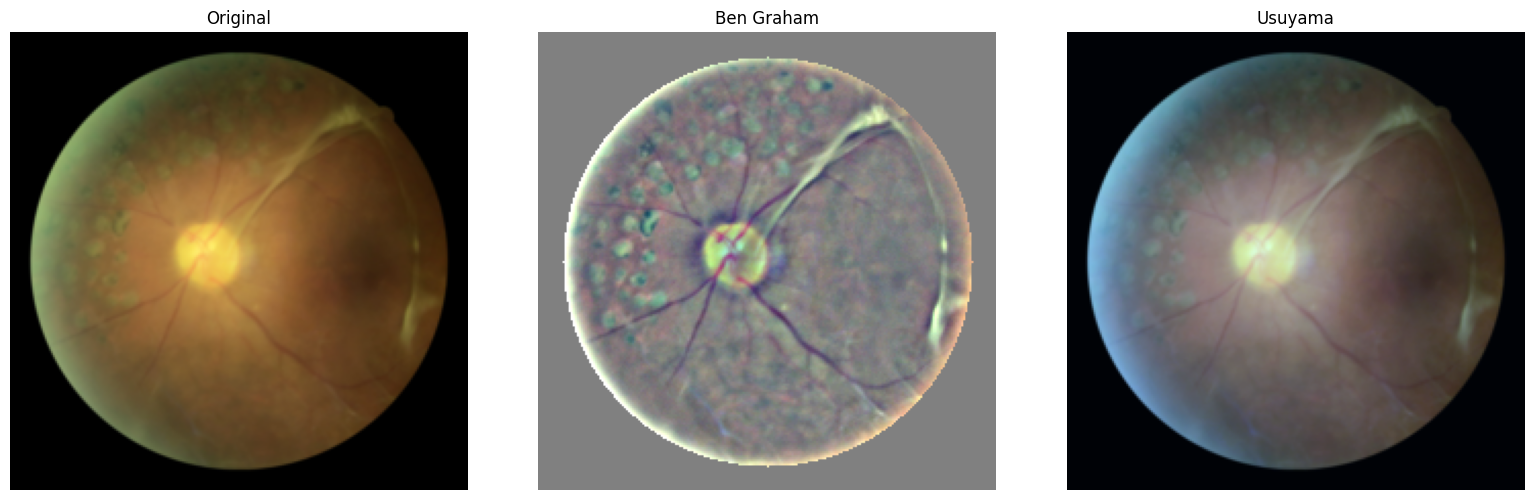

In [8]:
viz_class = 4

labels_flat = train_dataset.labels.flatten()
idx_sample = np.where(labels_flat == viz_class)[0][0]
sample = np.squeeze(train_dataset.imgs[idx_sample]).astype(np.uint8)

original = cv2.resize(sample, (224, 224))
bg = preprocess_ben_graham(sample, sigma=5)
usuyama = preprocess_usuyama(sample)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Original', 'Ben Graham', 'Usuyama']
for ax, img, title in zip(axes, [original, bg, usuyama], titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
splits = [
    ("train", train_dataset),
    ("val",   val_dataset),
    ("test",  test_dataset),
]

for split_name, dataset in splits:
    labels_flat = dataset.labels.flatten()
    class_counts: dict[int, int] = {}
    for i in tqdm(range(len(dataset)), desc=split_name):
        label = int(labels_flat[i])
        class_dir = os.path.join(PREPROCESSED_DIR, split_name, str(label))
        os.makedirs(class_dir, exist_ok=True)

        img = np.squeeze(dataset.imgs[i]).astype(np.uint8)
        proc = preprocess_ben_graham(img)

        class_counts[label] = class_counts.get(label, 0) + 1
        fname = f"{class_counts[label]:05d}.png"
        Image.fromarray(proc).save(os.path.join(class_dir, fname))

print(f"Images saved under {PREPROCESSED_DIR}/")

test: 100%|██████████| 400/400 [00:10<00:00, 39.41it/s]

Images saved under /content/preprocessed/


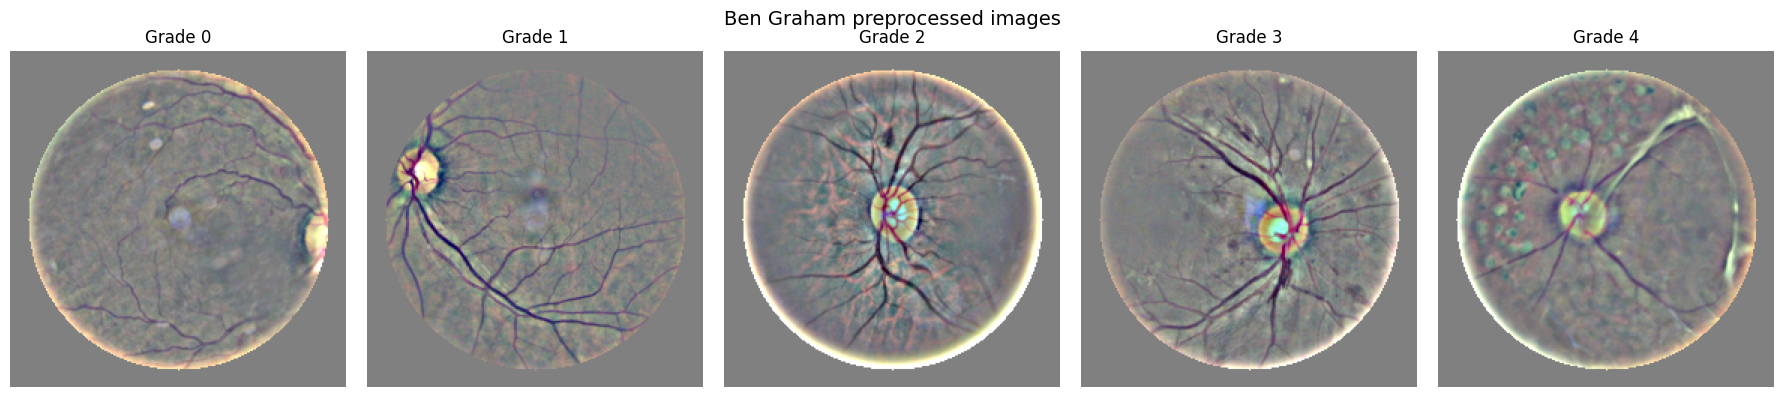

In [10]:
classes = np.unique(train_dataset.labels.flatten())
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, cls in enumerate(classes):
    labels_flat = train_dataset.labels.flatten()
    sample_idx = np.where(labels_flat == cls)[0][0]
    sample = np.squeeze(train_dataset.imgs[sample_idx]).astype(np.uint8)
    proc = preprocess_ben_graham(sample)

    axes[idx].imshow(proc)
    axes[idx].set_title(f"Grade {int(cls)}", fontsize=12)
    axes[idx].axis("off")

fig.suptitle("Ben Graham preprocessed images", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
def load_preprocessed(split_name: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load saved preprocessed images and labels.
    
    Args:
        split_name (str): Name of the dataset split ('train', 'val', or 'test').
    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing:
            - imgs: A numpy array of shape (N, H, W, C) containing the preprocessed images.
            - labels: A numpy array of shape (N,) containing the corresponding labels for the images.
    """
    split_dir = os.path.join(PREPROCESSED_DIR, split_name)
    imgs, labels = [], []
    class_dirs = sorted(os.listdir(split_dir))
    for cls_dir in class_dirs:
        cls = int(cls_dir)
        img_folder = os.path.join(split_dir, cls_dir)
        for fname in sorted(os.listdir(img_folder), key=lambda x: int(x.split(".")[0])):
            fpath = os.path.join(img_folder, fname)
            img = cv2.imread(fpath)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            imgs.append(img)
            labels.append(cls)
    return np.stack(imgs), np.array(labels)

train_proc_imgs, train_proc_labels = load_preprocessed("train")
val_proc_imgs, val_proc_labels = load_preprocessed("val")
test_proc_imgs, test_proc_labels = load_preprocessed("test")

print(f"Train: {train_proc_imgs.shape} | labels={train_proc_labels.shape}")
print(f"Val: {val_proc_imgs.shape} | labels={val_proc_labels.shape}")
print(f"Test: {test_proc_imgs.shape} | labels={test_proc_labels.shape}")

Train: (1080, 224, 224, 3) | labels=(1080,)
Val: (120, 224, 224, 3) | labels=(120,)
Test: (400, 224, 224, 3) | labels=(400,)


Per-channel statistics (training set — Ben Graham):
 Channel     Mean      Std    Min    Max
       R   130.81    19.77      0    255
       G   129.74    19.15      0    255
       B   129.03    11.60      0    255

Mean (normalized): [0.31081352 0.31081352 0.31081352]
Std  (normalized): [0.1828112  0.1761836  0.15619852]


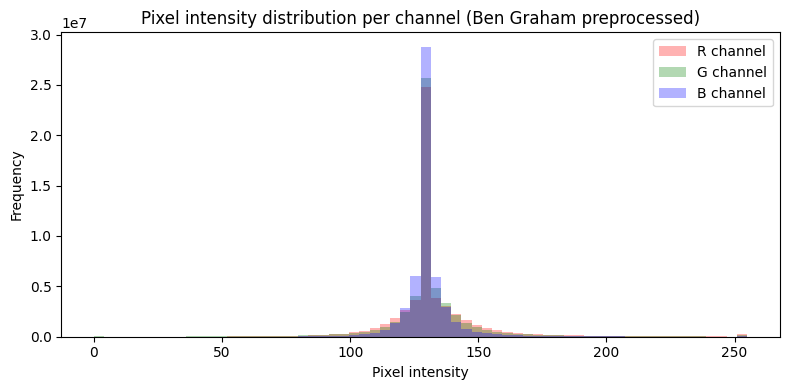

In [12]:
pixels = train_proc_imgs.reshape(-1, 3).astype(np.float32)

print("Per-channel statistics (training set — Ben Graham):")
print(f"{'Channel':>8} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
for ch, name in enumerate(['R', 'G', 'B']):
    data = pixels[:, ch]
    print(f"{name:>8} {data.mean():>8.2f} {data.std():>8.2f} "
          f"{int(data.min()):>6} {int(data.max()):>6}")

mean = pixels.mean(axis=0) / 255.0
std = pixels.std(axis=0) / 255.0

print(f"\nMean (normalized): {mean}")
print(f"Std  (normalized): {std}")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['red', 'green', 'blue']
for ch, color in enumerate(colors):
    ax.hist(pixels[:, ch], bins=64, color=color, alpha=0.3,
            label=f'{["R","G","B"][ch]} channel')
ax.set_xlabel('Pixel intensity')
ax.set_ylabel('Frequency')
ax.set_title('Pixel intensity distribution per channel (Ben Graham preprocessed)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Data augmentation

To avoid the alteration of features that are clinically important for diagnosis, we apply only simple augmentations, such as **random horizontal and vertical flips**, and **random rotations**. We avoid augmentations that could change the appearance of lesions or other important features, involving colors, brightness, or contrast. We also avoid cropping or resizing that could remove important parts of the retina.

In [13]:
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=20, fill=128),  # fill with Ben Graham background gray
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

eval_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

train_data = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "train"), transform=train_transforms)
val_data = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "val"),   transform=eval_transforms)
test_data = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "test"),  transform=eval_transforms)

print(f"Train: {len(train_data)} samples, classes={train_data.classes}")
print(f"Val: {len(val_data)} samples, classes={val_data.classes}")
print(f"Test: {len(test_data)} samples, classes={test_data.classes}")

Train: 1080 samples, classes=['0', '1', '2', '3', '4']
Val: 120 samples, classes=['0', '1', '2', '3', '4']
Test: 400 samples, classes=['0', '1', '2', '3', '4']
